# Edge IIoT - Exploratory Data Analysis (EDA)

In [62]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['raw_path']}\n")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw



## Selected dataset for Machine Learning (ML)

### Loading

In [63]:
csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / "ML-EdgeIIoT-dataset.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df_ml = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df_ml.shape}")

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (157800, 63)


### Types & Null values

In [64]:
quality_summary = pd.DataFrame({
    'Type': df_ml.dtypes,
    'Null': df_ml.isnull().sum(),
    '% Null': ((df_ml.isnull().sum() / len(df_ml)) * 100).map("{:.2f}%".format)
})

display(quality_summary)

,Type,Null,% Null
frame.time,str,0,0.00%
ip.src_host,str,0,0.00%
ip.dst_host,str,0,0.00%
arp.dst.proto_ipv4,str,0,0.00%
arp.opcode,float64,0,0.00%
...,...,...,...
mbtcp.len,float64,0,0.00%
mbtcp.trans_id,float64,0,0.00%
mbtcp.unit_id,float64,0,0.00%
Attack_label,int64,0,0.00%


### Target label (Attack type) distribution

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df_data, label_col):

    conteo = df_data[label_col].value_counts()
    labels = conteo.index
    sizes = conteo.values

    palette_colors = sns.color_palette("viridis", len(labels))
    color_map = dict(zip(labels, palette_colors))
    pie_colors = [color_map[label] for label in labels]
    explode = [0.05] * len(labels)

    # --- Barplot ---
    fig1, ax1 = plt.subplots(figsize=(8, 6))

    sns.countplot(y=label_col,
                  data=df_data,
                  ax=ax1,
                  order=labels,
                  hue=label_col,
                  palette=color_map,
                  legend=False)

    ax1.set_title(f"Count of each {label_col}")
    ax1.set_xlabel("Count")
    ax1.set_ylabel(label_col)

    plt.tight_layout()
    plt.show()

    # --- Donut ---
    fig2, ax2 = plt.subplots(figsize=(7, 7))

    ax2.pie(sizes,
            explode=explode,
            labels=labels,
            autopct='%1.1f%%',
            startangle=60,
            pctdistance=0.85,
            colors=pie_colors)

    center_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax2.add_artist(center_circle)

    ax2.set_title(f"Percentage of each {label_col}")

    plt.tight_layout()
    plt.show()

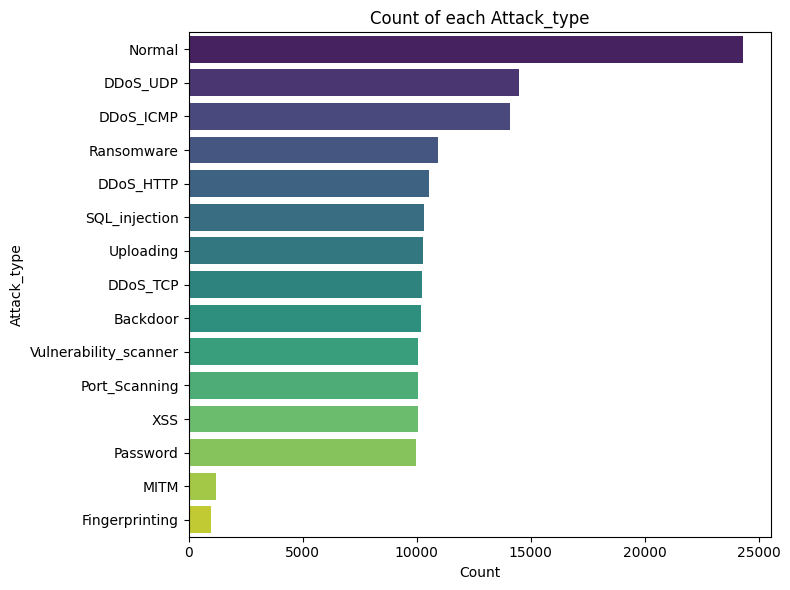

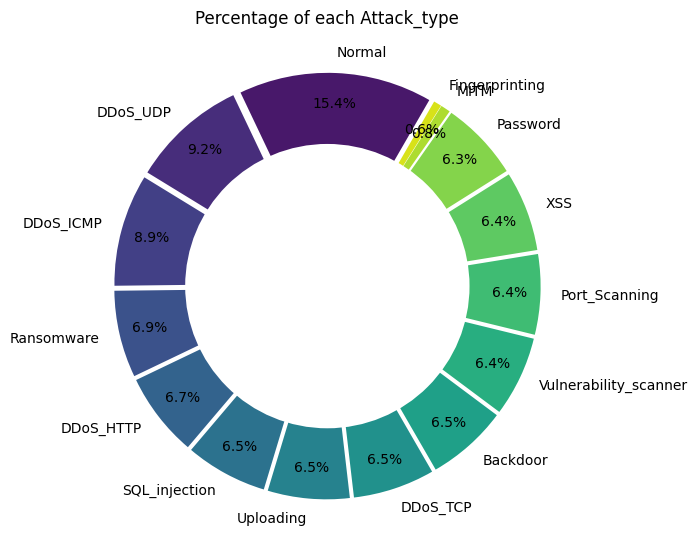

In [66]:
label_col = "Attack_type"
plot_label_distribution(df_ml, label_col)

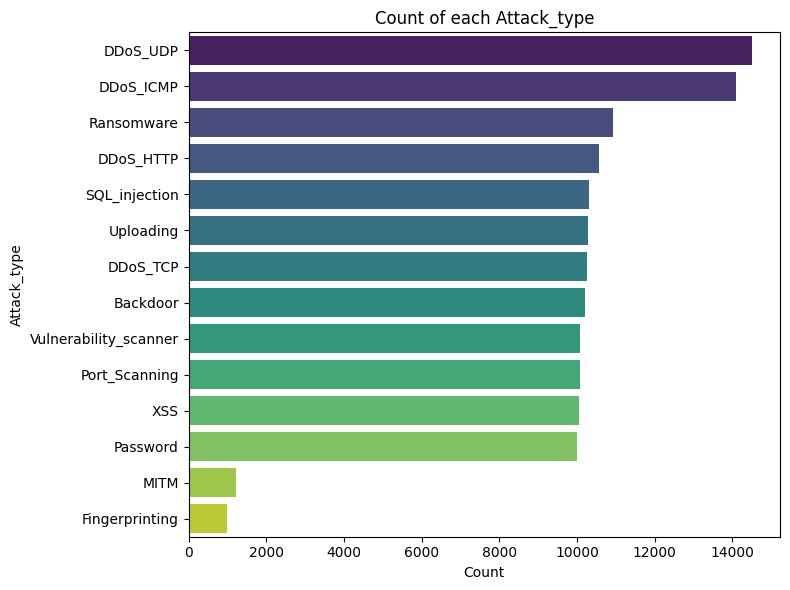

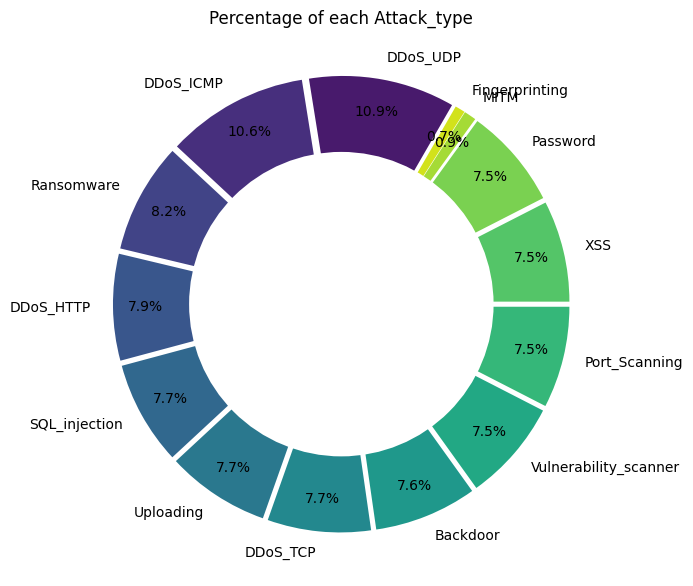

In [67]:
df_no_normal = df_ml[df_ml[label_col] != 'Normal']
plot_label_distribution(df_no_normal, label_col)

### Correlation Matrix

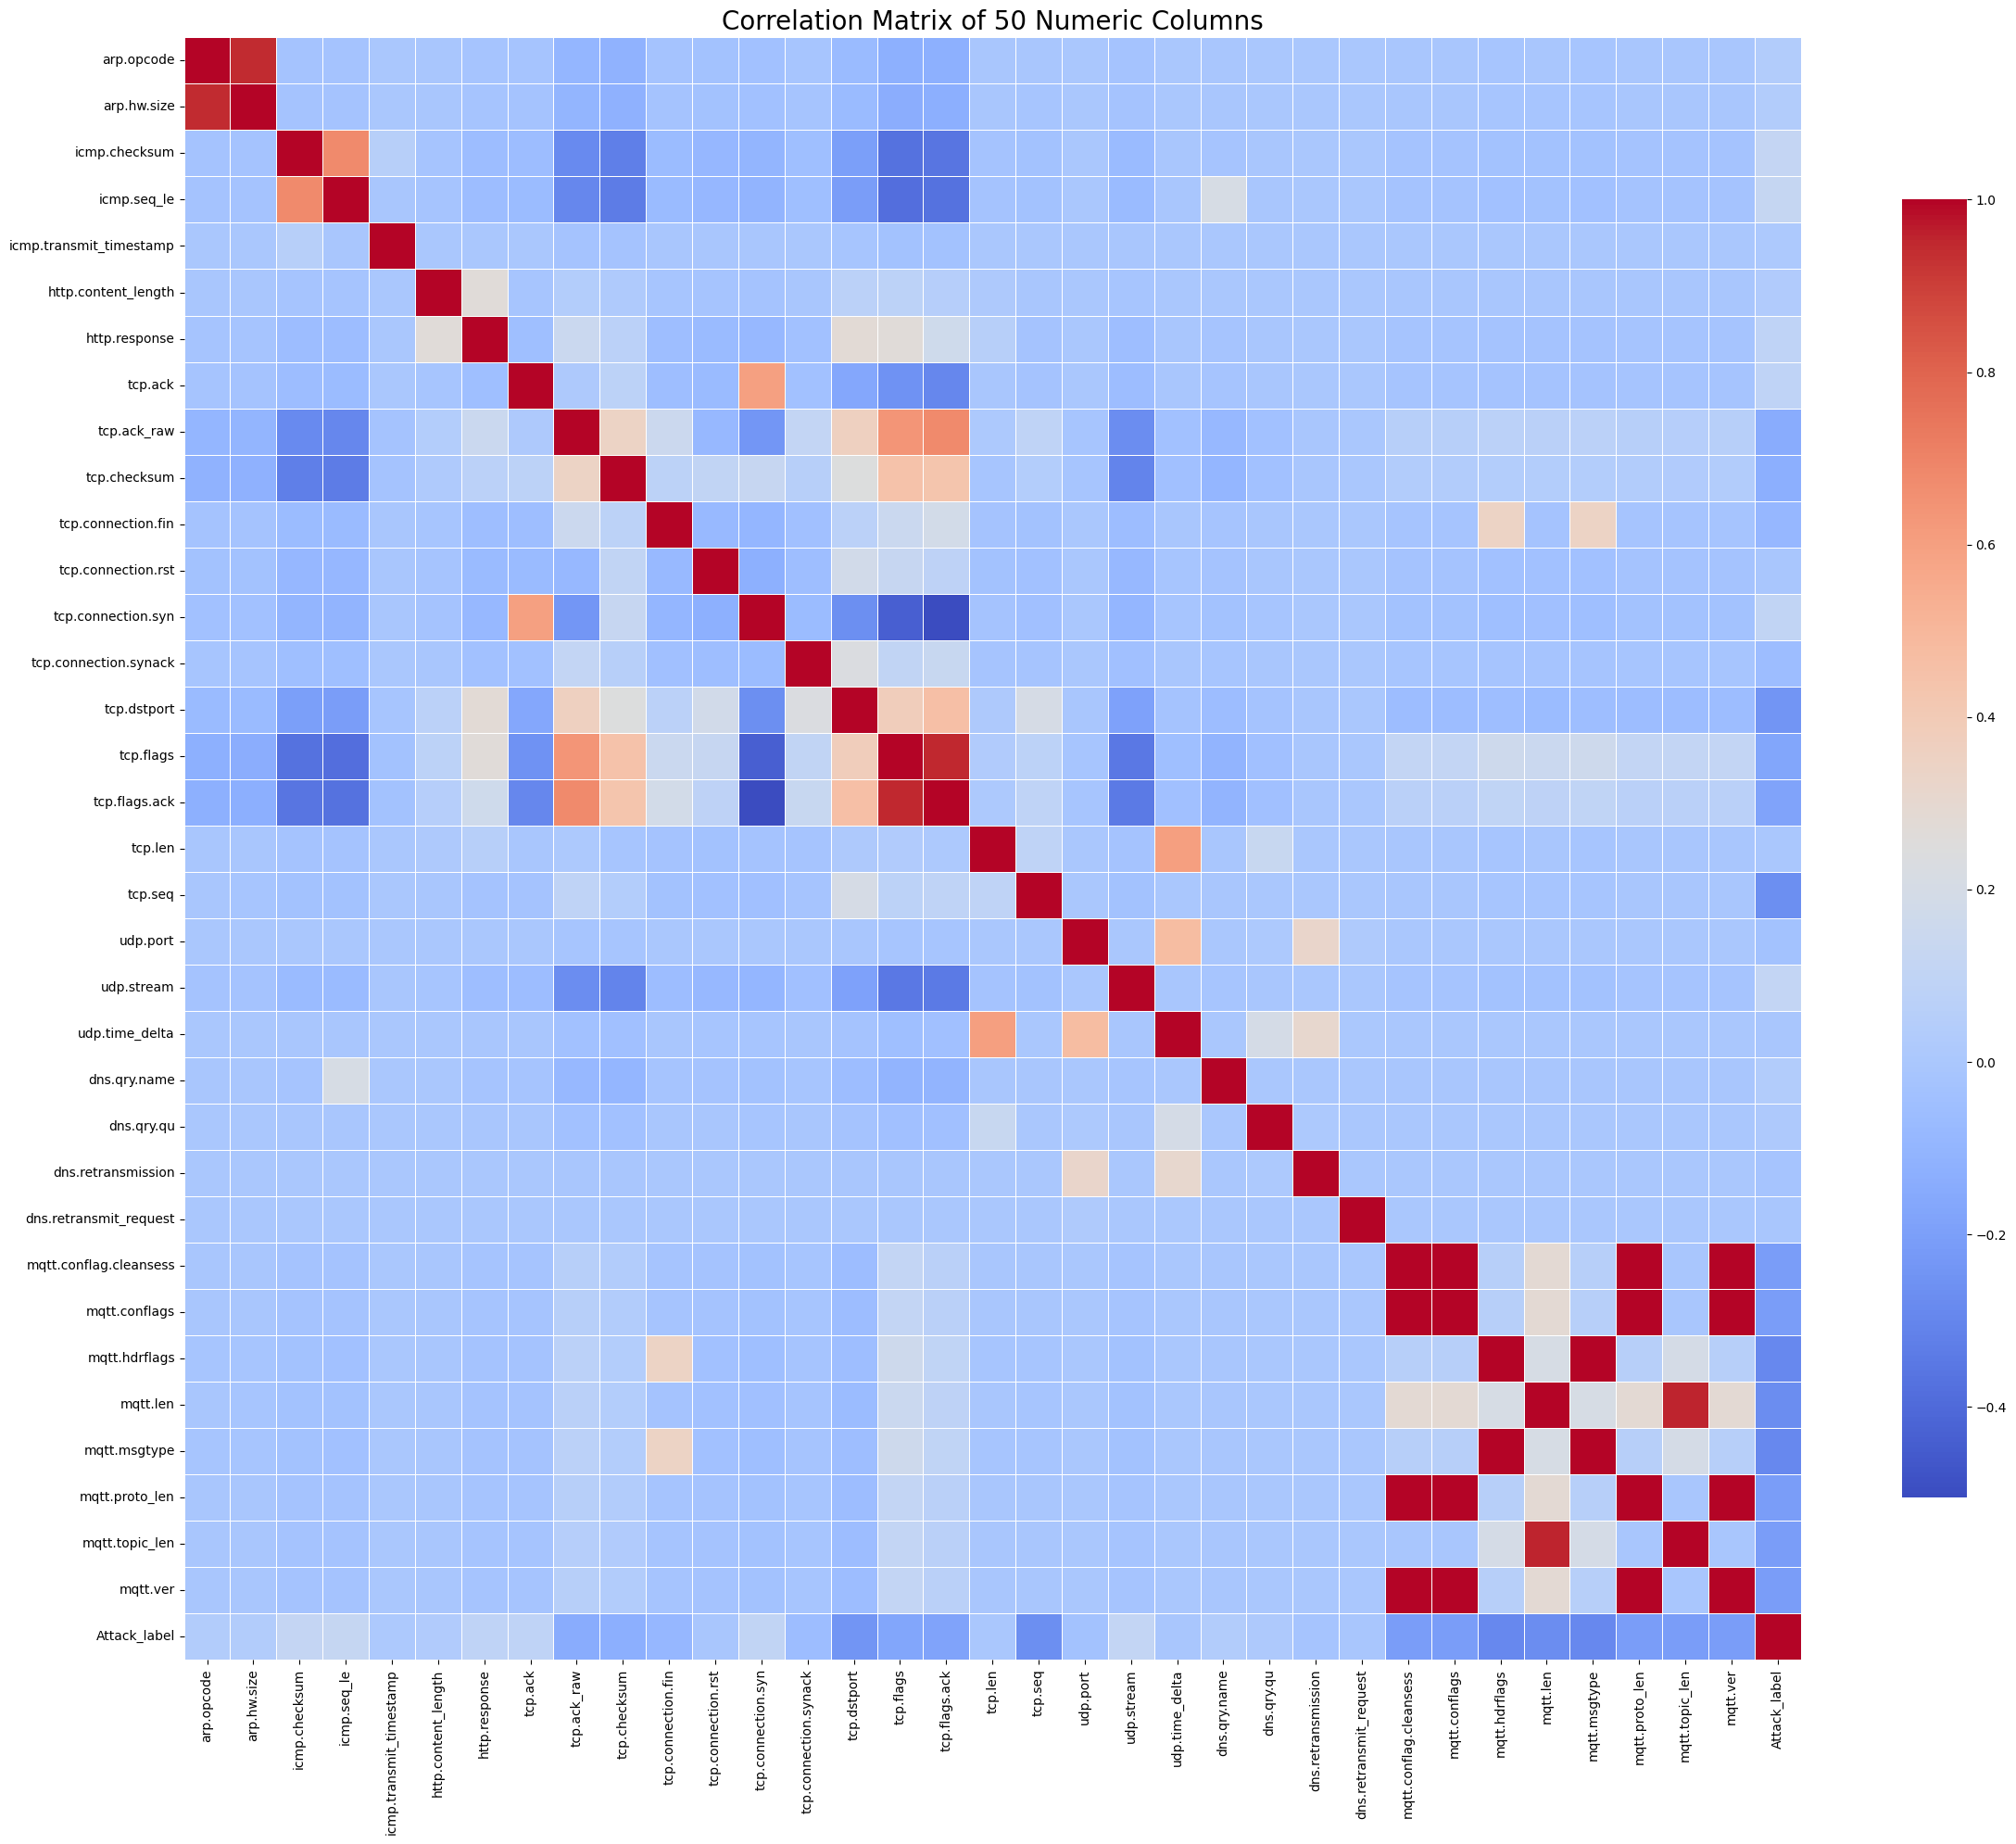

In [68]:
df_numeric = df_ml.select_dtypes(include=['int64', 'float64']) # Only the numeric columns
corr_matrix = df_numeric.corr()

corr_matrix = corr_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, 
            annot=False,
            cmap='coolwarm',
            linewidths=0.5,
            mask=corr_matrix.isnull(),
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix of 50 Numeric Columns", fontsize=20)
plt.tight_layout()
plt.show()

### Timeline

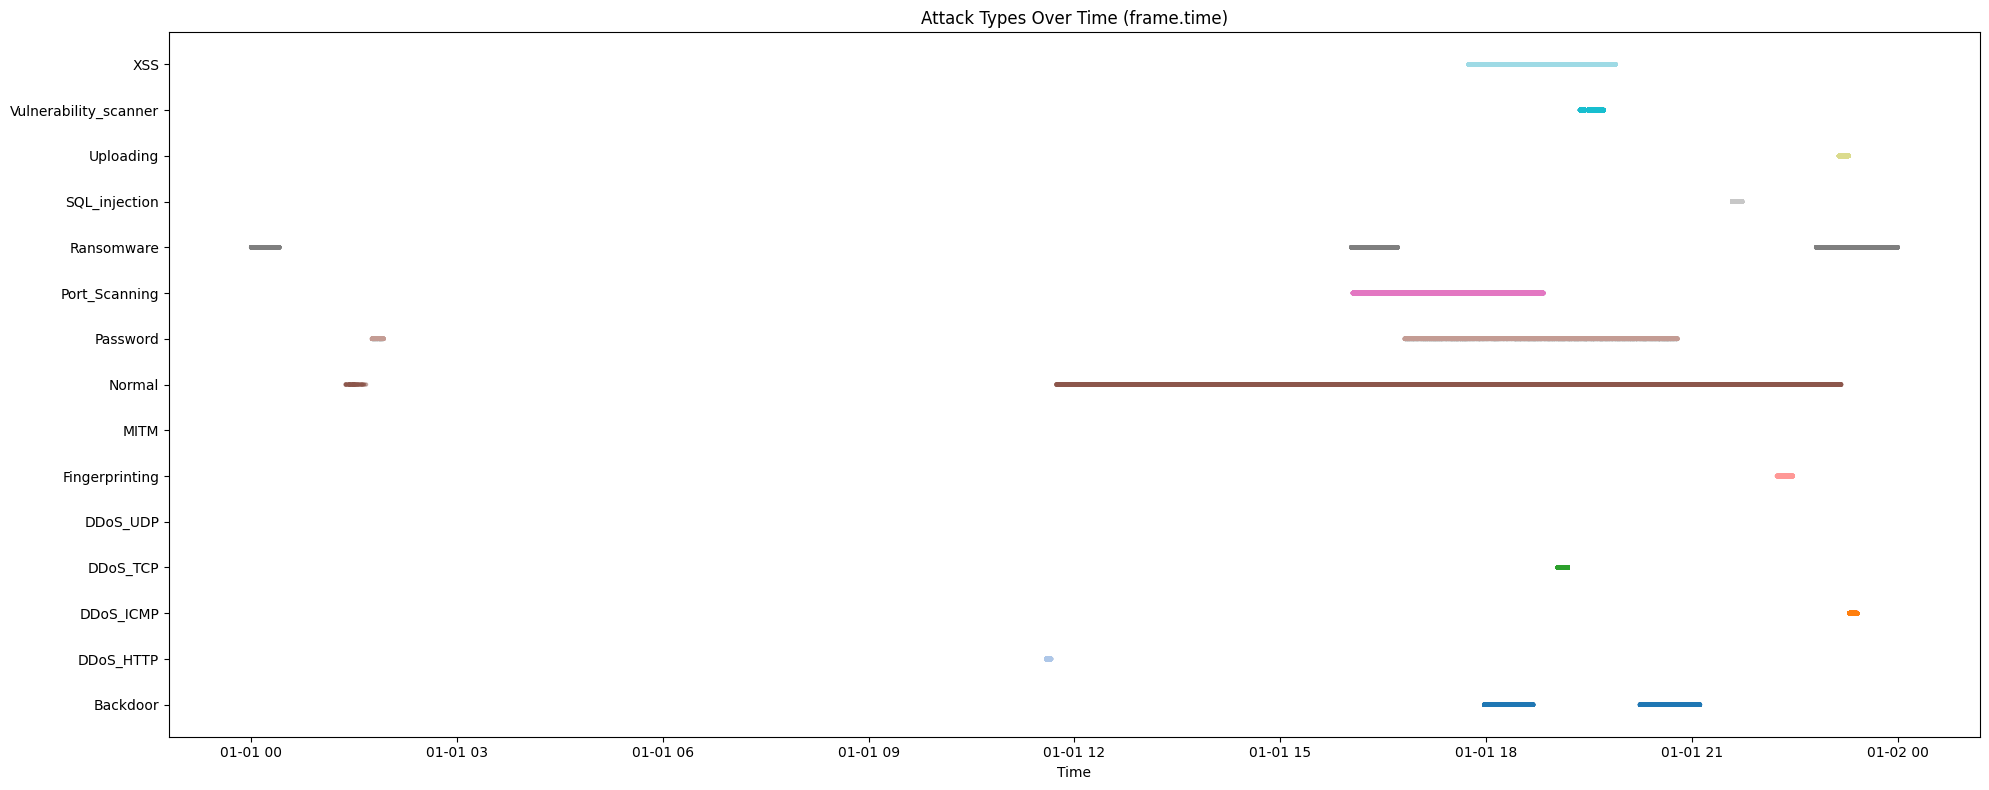

In [69]:
time_col = 'frame.time'
label_col = 'Attack_type'

# Convert to datetime
df_ml[time_col] = df_ml[time_col].str.strip()
converted = pd.to_datetime(
    df_ml[time_col], format="%Y %H:%M:%S.%f", exact=False, errors='coerce'
)
failed = converted.isna()
df_ml[time_col] = converted.dropna()
df_ml[time_col] = pd.to_datetime(df_ml[time_col], errors='coerce')

# Map each attack type to a numeric y-position
attack_types = df_ml[label_col].unique()
attack_map = {attack: i for i, attack in enumerate(sorted(attack_types))}
df_ml['attack_y'] = df_ml[label_col].map(attack_map)

plt.figure(figsize=(20, 8))
scatter = plt.scatter(
    df_ml[time_col], 
    df_ml['attack_y'],
    c=df_ml['attack_y'],
    cmap='tab20',
    alpha=0.4,
    s=5
)

plt.yticks(ticks=list(attack_map.values()), labels=list(attack_map.keys()), fontsize=10)
plt.xlabel("Time")
plt.title("Attack Types Over Time (frame.time)")
plt.tight_layout()
plt.show()

In [70]:
failed_per_type = df_ml.loc[failed, label_col].value_counts(dropna=False)
total_per_type = df_ml[label_col].value_counts(dropna=False)
summary = pd.DataFrame({
    'failed': failed_per_type,
    'total': total_per_type,
}).fillna(0).astype(int)
summary['percentaje_failed'] = (summary['failed'] / summary['total'] * 100).round(2)
print(summary.sort_values('percentaje_failed', ascending=False))

                       failed  total  percentaje_failed
Attack_type                                            
DDoS_UDP                14498  14498              100.0
MITM                     1214   1214              100.0
Backdoor                    0  10195                0.0
DDoS_ICMP                   0  14090                0.0
DDoS_HTTP                   0  10561                0.0
DDoS_TCP                    0  10247                0.0
Fingerprinting              0   1001                0.0
Normal                      0  24301                0.0
Password                    0   9989                0.0
Port_Scanning               0  10071                0.0
Ransomware                  0  10925                0.0
SQL_injection               0  10311                0.0
Uploading                   0  10269                0.0
Vulnerability_scanner       0  10076                0.0
XSS                         0  10052                0.0


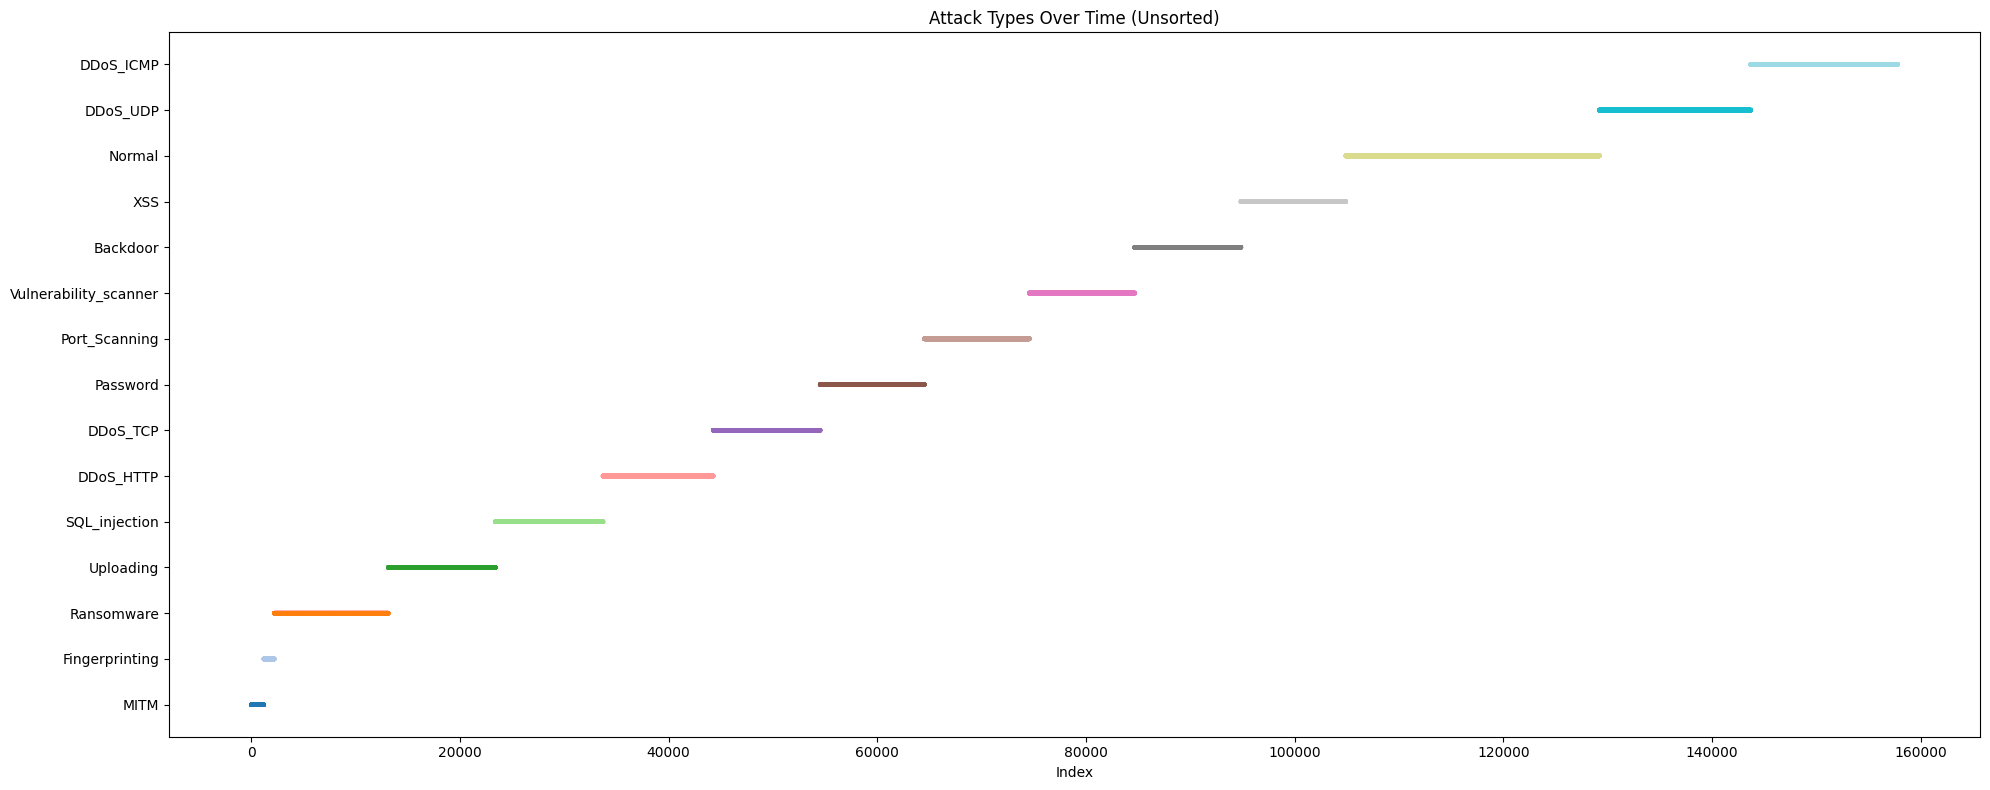

In [71]:
label_col = 'Attack_type'

# Map each attack type to a numeric y-position
attack_types = df_ml[label_col].unique()
attack_map = {attack: i for i, attack in enumerate(attack_types)}
df_ml['attack_y'] = df_ml[label_col].map(attack_map)

plt.figure(figsize=(20, 8))
scatter = plt.scatter(
    df_ml.index,
    df_ml['attack_y'],
    c=df_ml['attack_y'],
    cmap='tab20',
    alpha=0.4,
    s=5
)

plt.yticks(ticks=list(attack_map.values()), labels=list(attack_map.keys()), fontsize=10)
plt.xlabel("Index")
plt.title("Attack Types Over Time (Unsorted)")
plt.tight_layout()
plt.show()

## Selected dataset for Deep Learning (DL)

### Loading

In [72]:
csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / "DNN-EdgeIIoT-dataset.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df_dl = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df_dl.shape}")

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (2219201, 63)


### Types & Null values

In [73]:
quality_summary = pd.DataFrame({
    'Type': df_dl.dtypes,
    'Null': df_dl.isnull().sum(),
    '% Null': ((df_dl.isnull().sum() / len(df_dl)) * 100).map("{:.2f}%".format)
})

display(quality_summary)

,Type,Null,% Null
frame.time,str,0,0.00%
ip.src_host,str,0,0.00%
ip.dst_host,str,0,0.00%
arp.dst.proto_ipv4,str,0,0.00%
arp.opcode,float64,0,0.00%
...,...,...,...
mbtcp.len,float64,0,0.00%
mbtcp.trans_id,float64,0,0.00%
mbtcp.unit_id,float64,0,0.00%
Attack_label,int64,0,0.00%


### Target label (Attack type) distribution


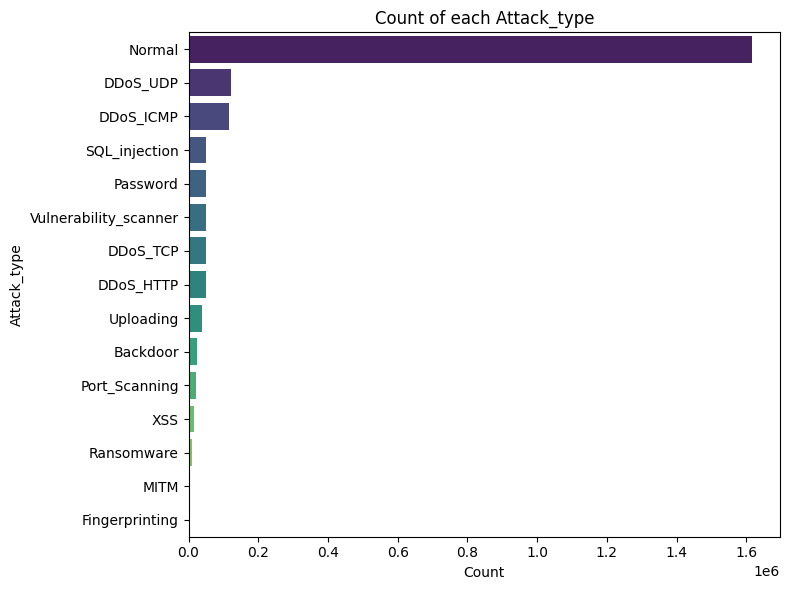

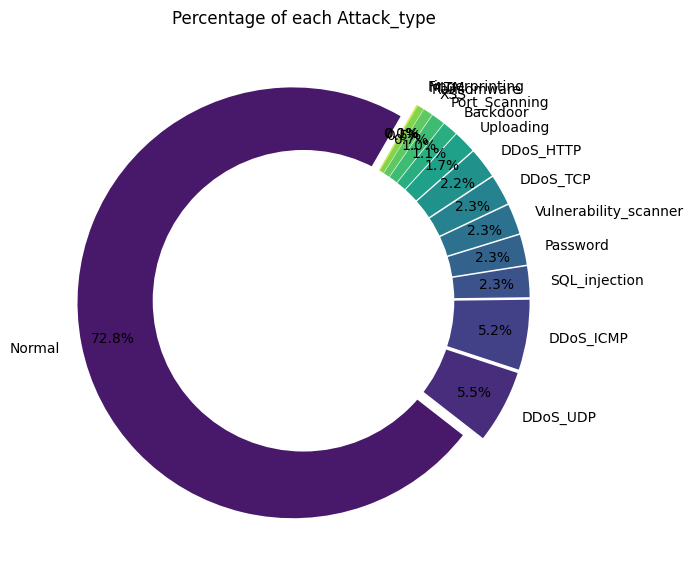

In [74]:
label_col = "Attack_type"
plot_label_distribution(df_dl, label_col)

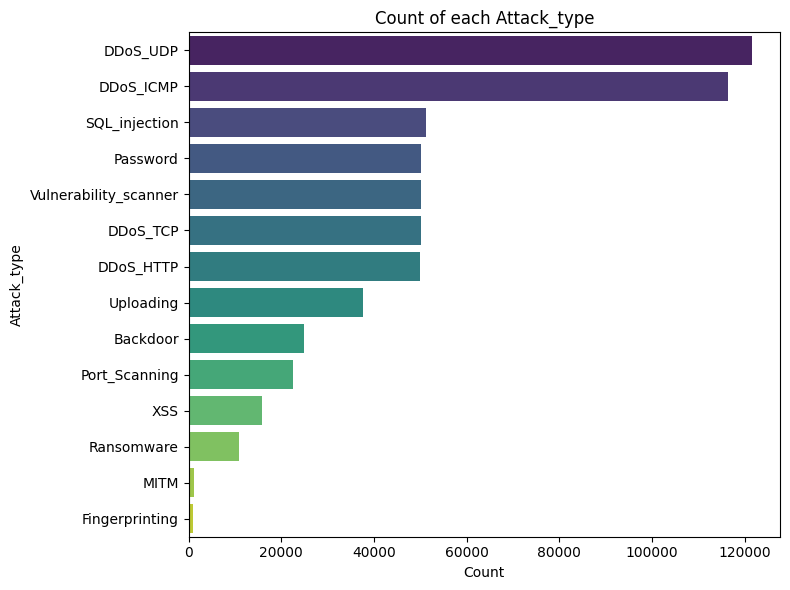

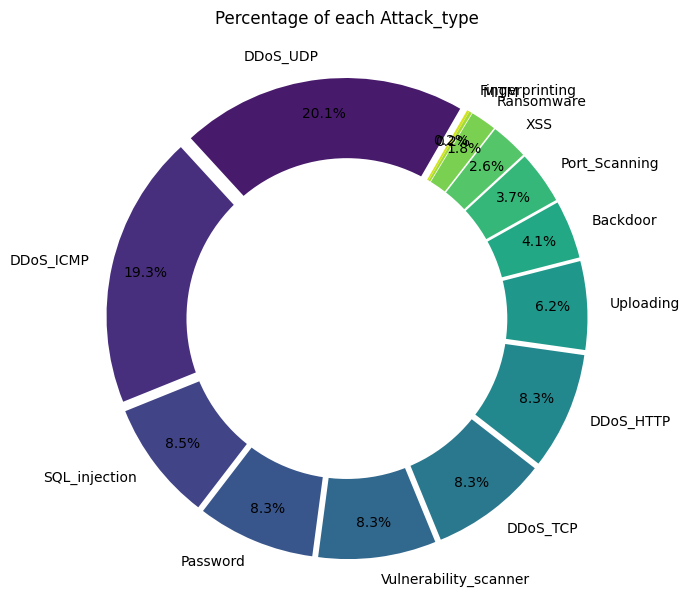

In [75]:
df_no_normal = df_dl[df_dl[label_col] != 'Normal']
plot_label_distribution(df_no_normal, label_col)

### Correlation Matrix

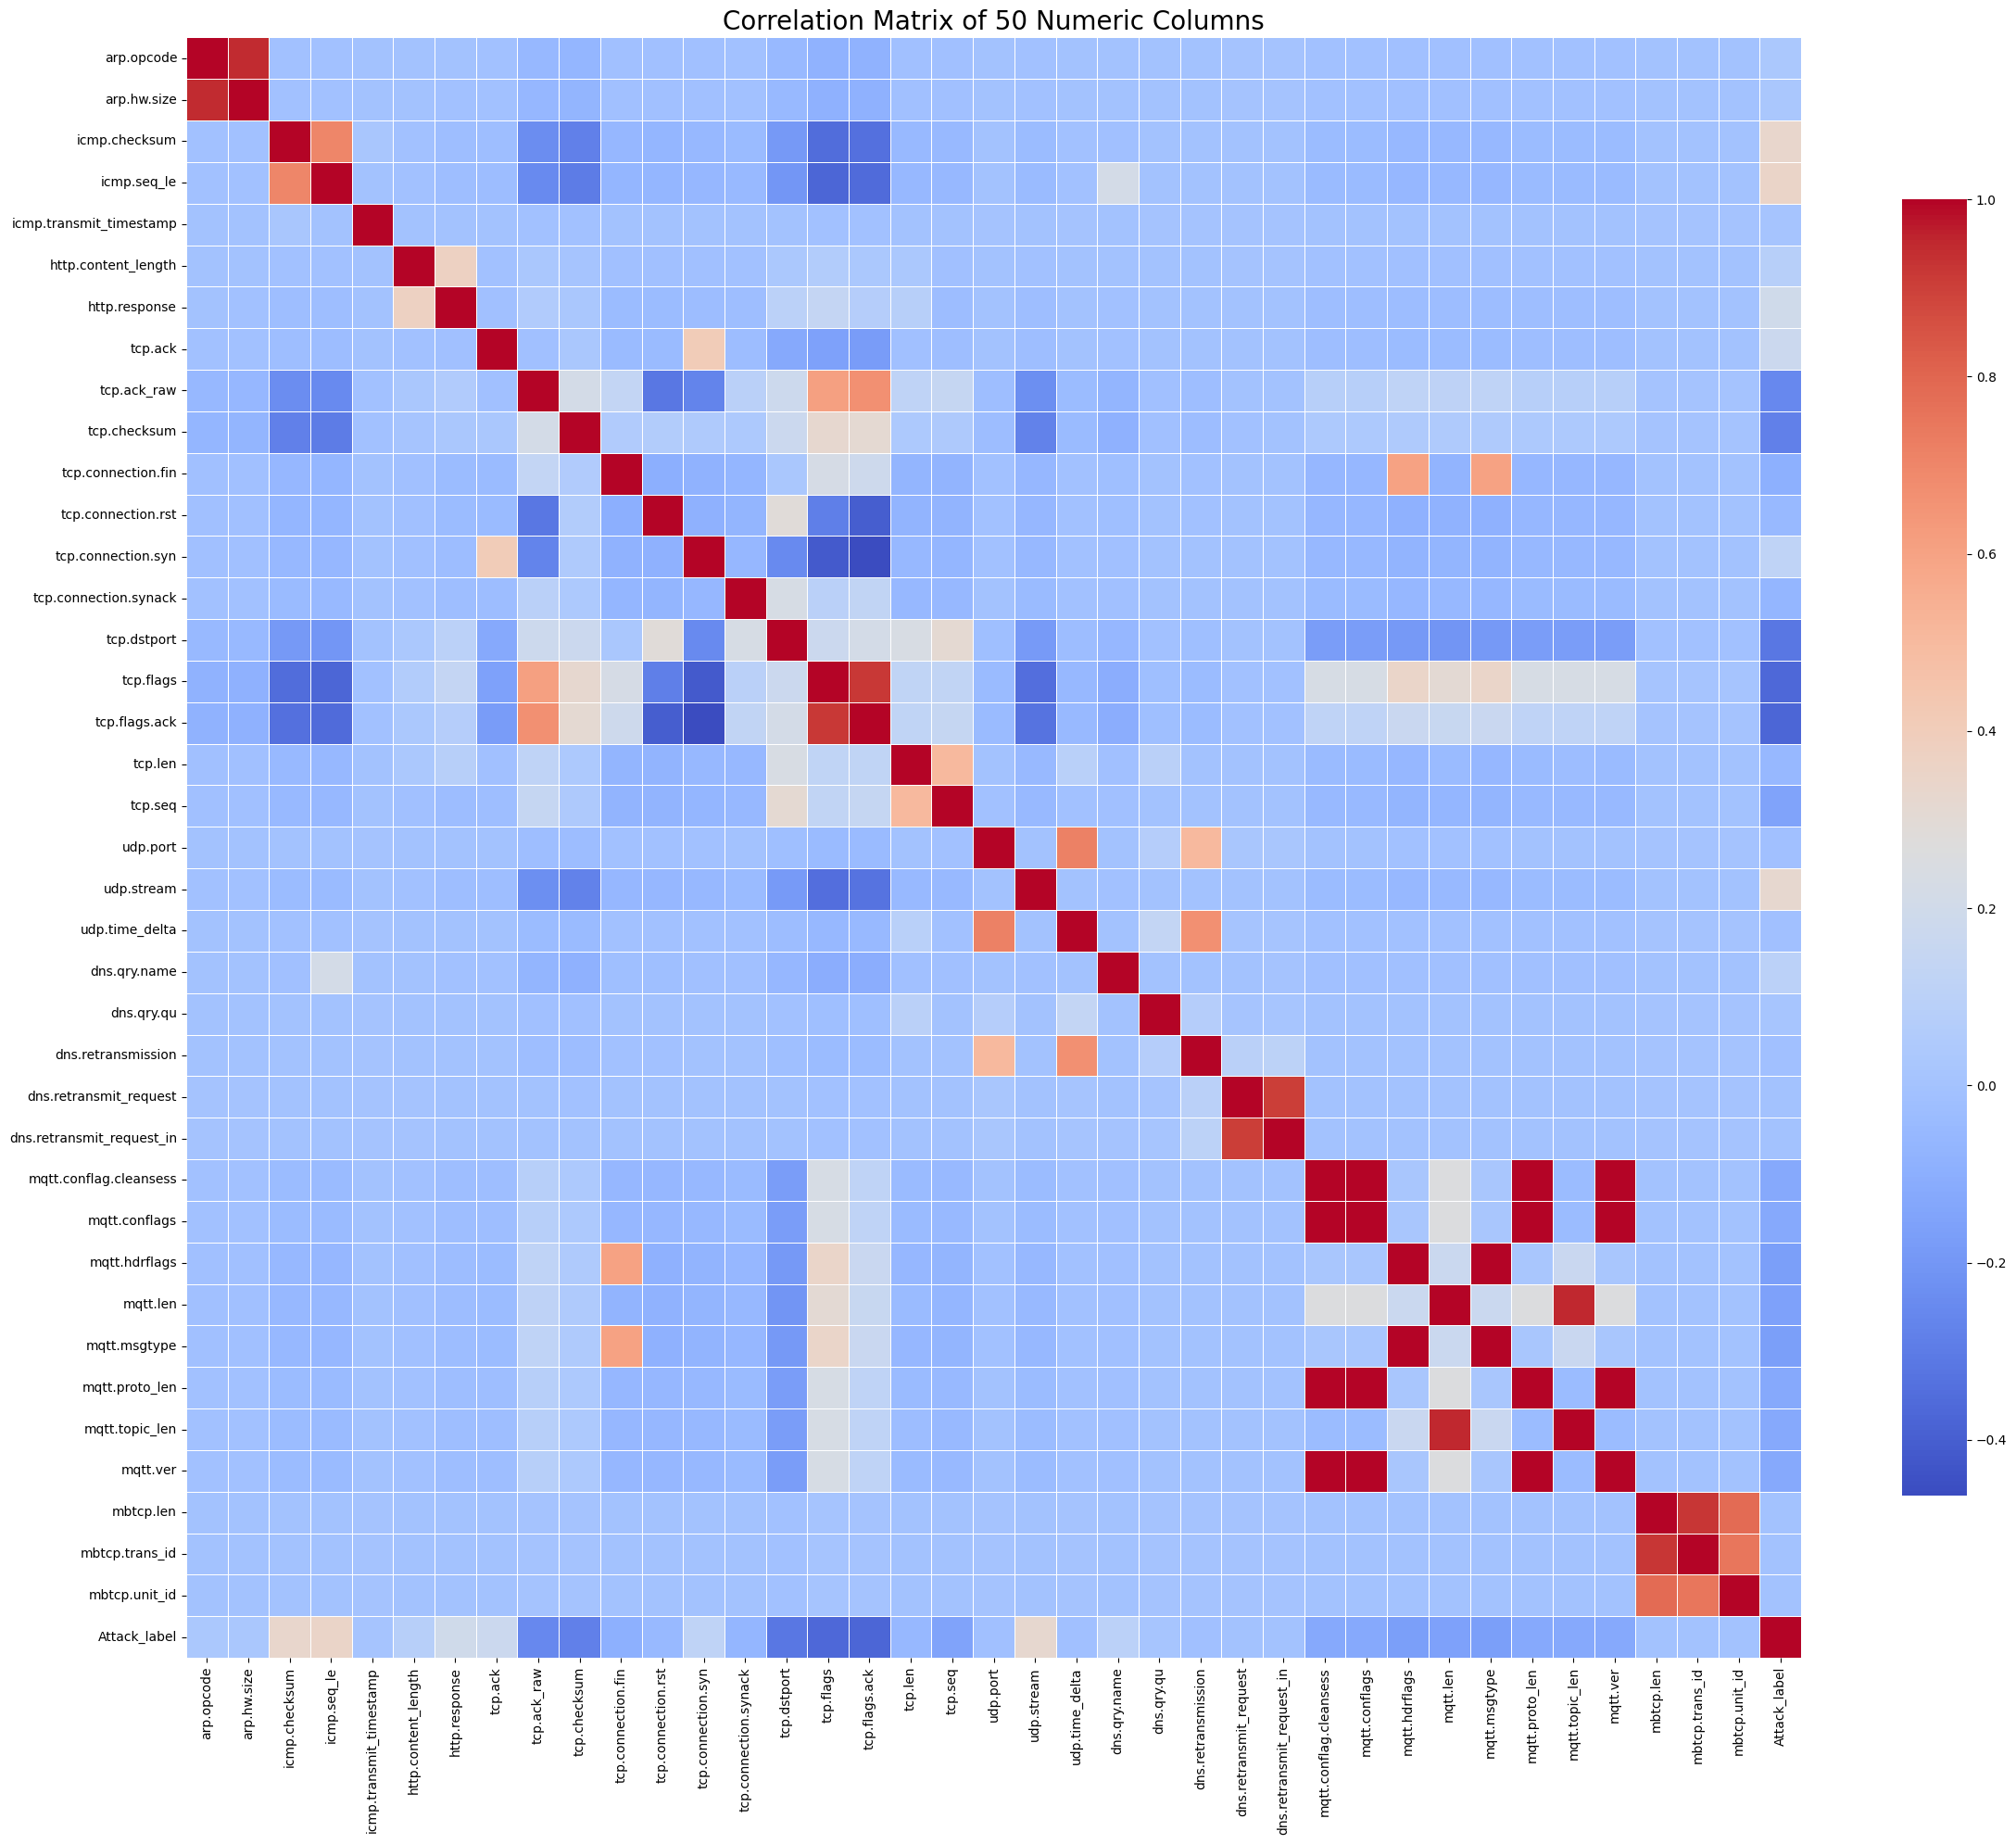

In [76]:
df_numeric = df_dl.select_dtypes(include=['int64', 'float64']) # Only the numeric columns
corr_matrix = df_numeric.corr()

corr_matrix = corr_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, 
            annot=False,
            cmap='coolwarm',
            linewidths=0.5,
            mask=corr_matrix.isnull(),
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix of 50 Numeric Columns", fontsize=20)
plt.tight_layout()
plt.show()

### Timeline

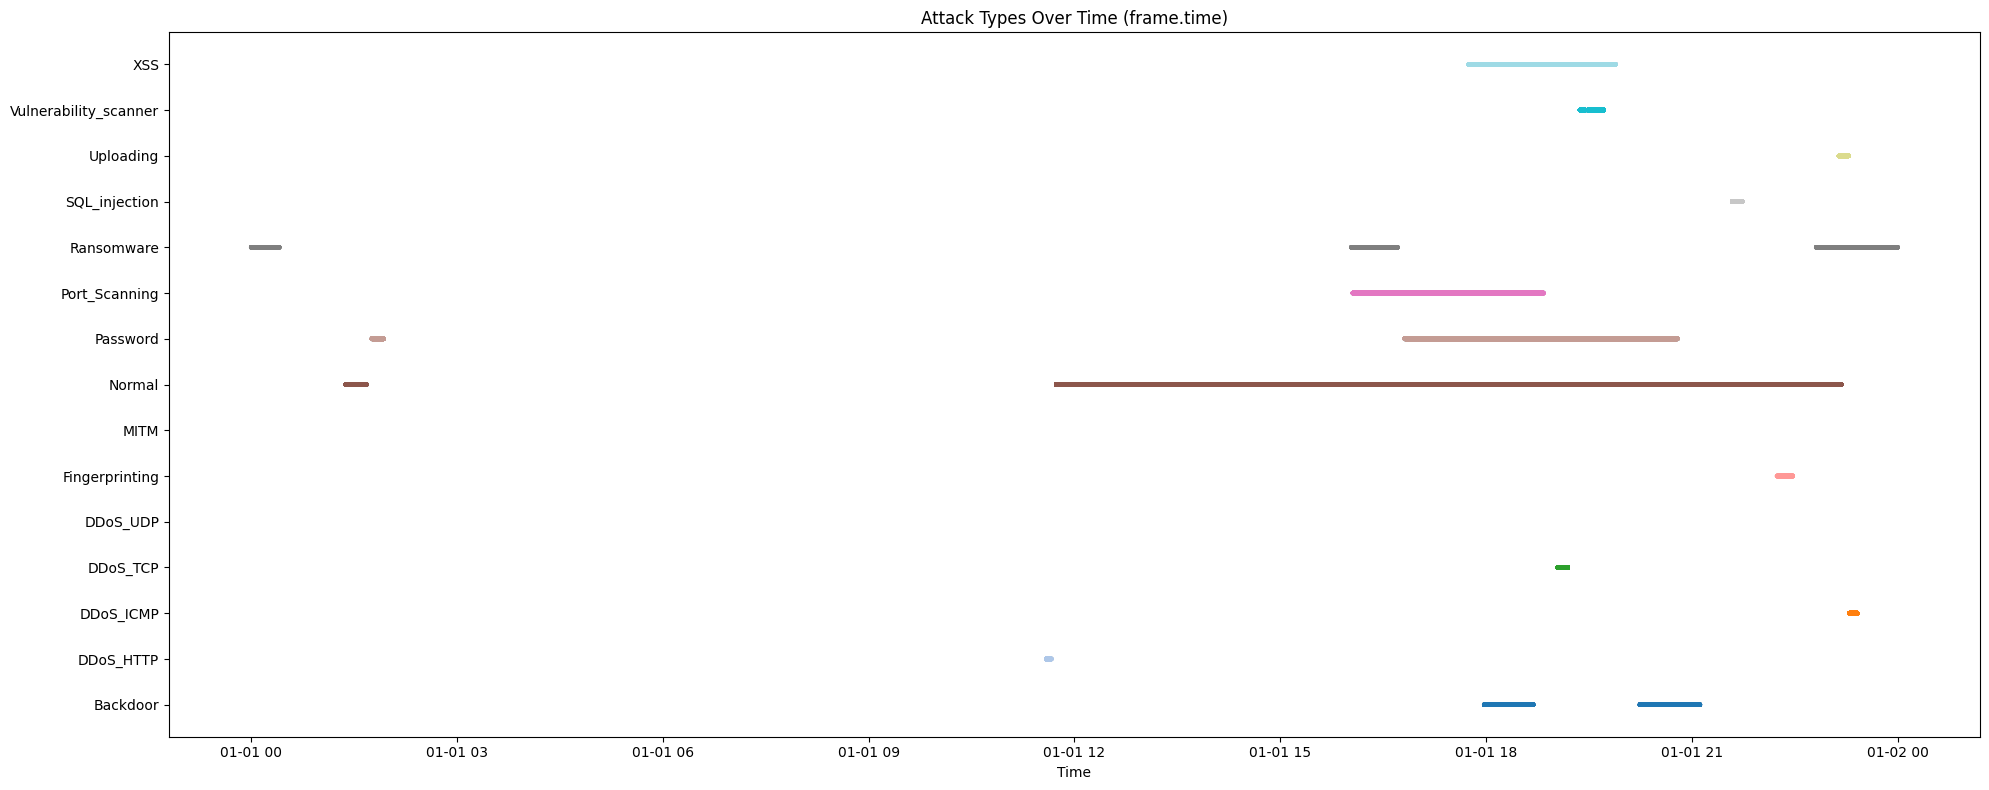

In [77]:
time_col = 'frame.time'
label_col = 'Attack_type'

# Convert to datetime
df_dl[time_col] = df_dl[time_col].str.strip()
converted = pd.to_datetime(
    df_dl[time_col], format="%Y %H:%M:%S.%f", exact=False, errors='coerce'
)
failed = converted.isna()
df_dl[time_col] = converted.dropna()
df_dl[time_col] = pd.to_datetime(df_dl[time_col], errors='coerce')

# Map each attack type to a numeric y-position
attack_types = df_dl[label_col].unique()
attack_map = {attack: i for i, attack in enumerate(sorted(attack_types))}
df_dl['attack_y'] = df_dl[label_col].map(attack_map)

plt.figure(figsize=(20, 8))
scatter = plt.scatter(
    df_dl[time_col], 
    df_dl['attack_y'],
    c=df_dl['attack_y'],
    cmap='tab20',
    alpha=0.4,
    s=5
)

plt.yticks(ticks=list(attack_map.values()), labels=list(attack_map.keys()), fontsize=10)
plt.xlabel("Time")
plt.title("Attack Types Over Time (frame.time)")
plt.tight_layout()
plt.show()

In [78]:
failed_per_type = df_dl.loc[failed, label_col].value_counts(dropna=False)
total_per_type = df_dl[label_col].value_counts(dropna=False)
summary = pd.DataFrame({
    'failed': failed_per_type,
    'total': total_per_type,
}).fillna(0).astype(int)
summary['percentaje_failed'] = (summary['failed'] / summary['total'] * 100).round(2)
print(summary.sort_values('percentaje_failed', ascending=False))

                       failed    total  percentaje_failed
Attack_type                                              
DDoS_UDP               121568   121568              100.0
MITM                     1214     1214              100.0
Backdoor                    0    24862                0.0
DDoS_ICMP                   0   116436                0.0
DDoS_HTTP                   0    49911                0.0
DDoS_TCP                    0    50062                0.0
Fingerprinting              0     1001                0.0
Normal                      0  1615643                0.0
Password                    0    50153                0.0
Port_Scanning               0    22564                0.0
Ransomware                  0    10925                0.0
SQL_injection               0    51203                0.0
Uploading                   0    37634                0.0
Vulnerability_scanner       0    50110                0.0
XSS                         0    15915                0.0


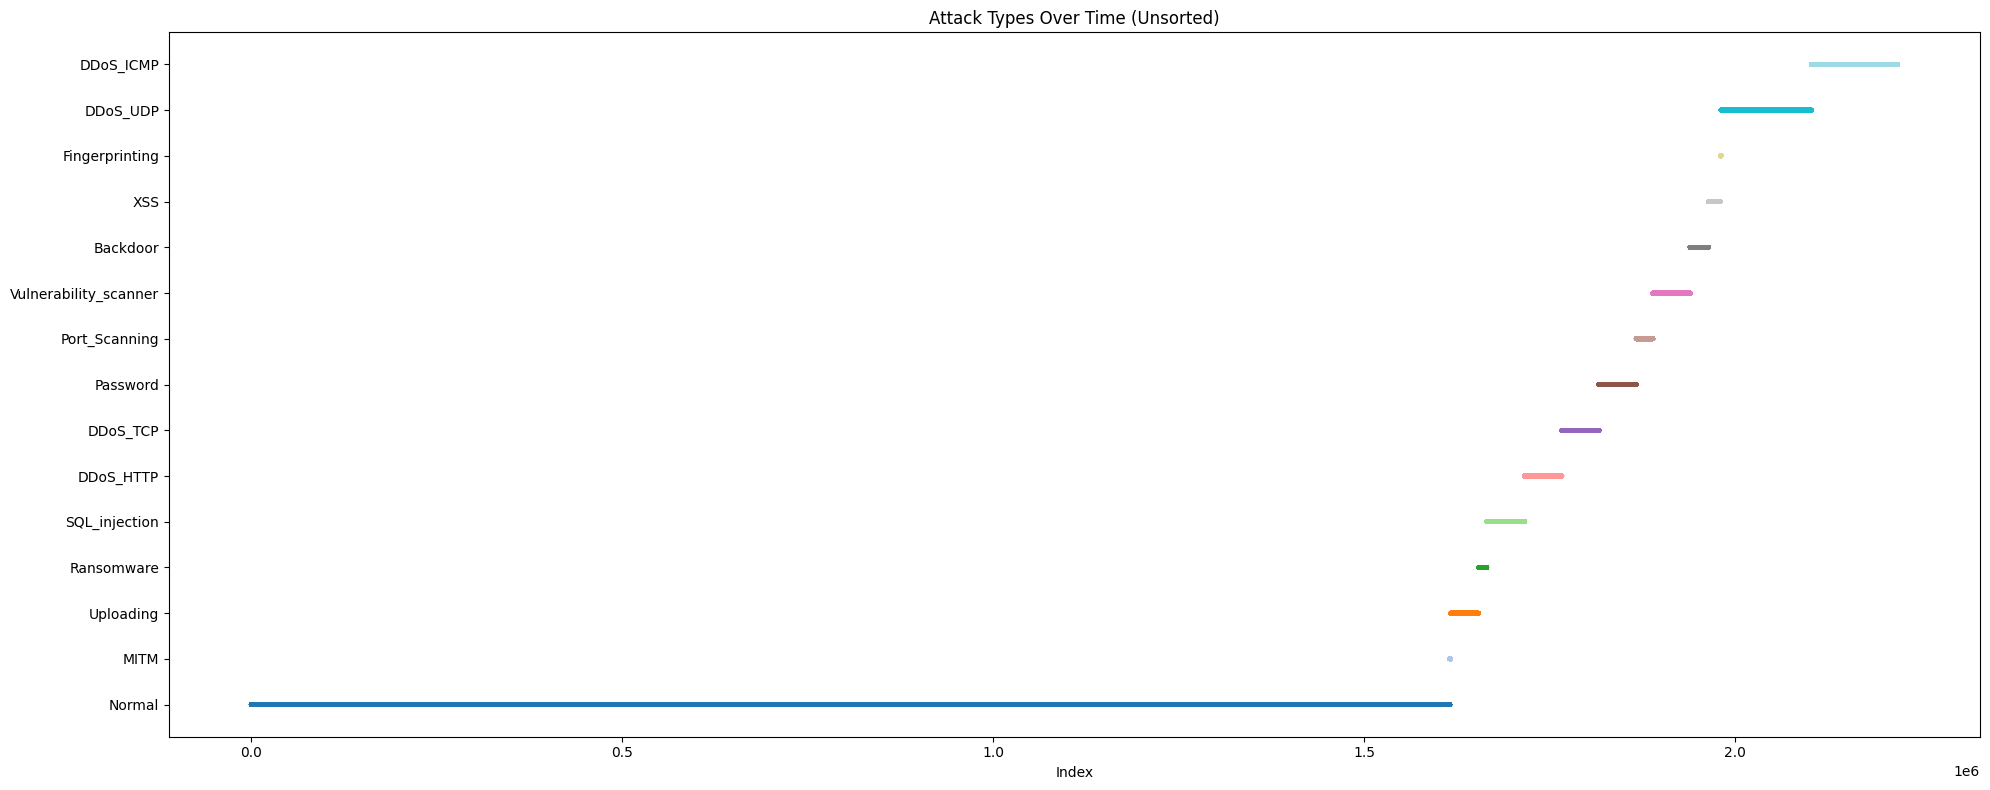

In [79]:
label_col = 'Attack_type'

# Use dataset order, not sorted
attack_types = df_dl[label_col].unique()
attack_map = {attack: i for i, attack in enumerate(attack_types)}
df_dl['attack_y'] = df_dl[label_col].map(attack_map)

plt.figure(figsize=(20, 8))
scatter = plt.scatter(
    df_dl.index,
    df_dl['attack_y'],
    c=df_dl['attack_y'],
    cmap='tab20',
    alpha=0.4,
    s=5
)

plt.yticks(ticks=list(attack_map.values()), labels=list(attack_map.keys()), fontsize=10)
plt.xlabel("Index")
plt.title("Attack Types Over Time (Unsorted)")
plt.tight_layout()
plt.show()